In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from pandas import read_csv


df = read_csv('movie_review - movie_review.csv')

In [ ]:
def clean_text(text):
    text = re.sub(r'<.*?>','',text)
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()
    return text   



In [ ]:
df['review '] = df['review'].apply(clean_text)

In [ ]:
X= df['review']
Y= df['sentiment']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
    )

In [ ]:
ignore_words = {'no','not'}
custom_stop_words = list(set('ENGLISH_STOP_WORDS') - ignore_words)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

tfidf = TfidfVectorizer(stop_words=custom_stop_words, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [16]:
model = MultinomialNB(alpha=0.1) #default value 1
model.fit(X_train_tfidf,Y_train)
Y_pred = model.predict(X_test_tfidf)
cr = classification_report(Y_test,Y_pred)

In [17]:
cr= classification_report(Y_test,Y_pred)
cm = confusion_matrix(Y_test,Y_pred)
print(cm)
print(cr)

[[4497  464]
 [ 565 4474]]
              precision    recall  f1-score   support

    negative       0.89      0.91      0.90      4961
    positive       0.91      0.89      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



<Axes: >

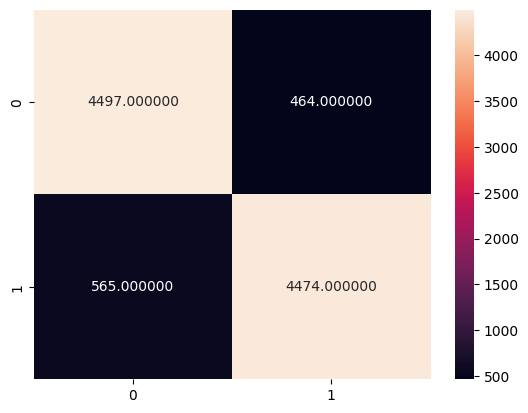

In [18]:
sns.heatmap(cm, annot= True, fmt='0f')

SyntaxError: invalid syntax (712365739.py, line 1)